# Pre-trained network (VGG 16) [[lab3](https://mdig.agh.edu.pl/dokuwiki/doku.php?id=teaching:data_science:dnn:lab3#pre-trained_network_vgg_16)]

In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
from keras import models
from keras import layers
from keras import optimizers
from keras.applications import VGG16

data_augmentation = models.Sequential(
    [
        layers.RandomFlip("horizontal", seed=1),
        layers.RandomRotation(1.0 / 9, fill_mode="nearest", seed=1),
        layers.RandomZoom(0.2, fill_mode="nearest", seed=1),
        layers.RandomTranslation(
            height_factor=0.2, width_factor=0.2, fill_mode="nearest", seed=1
        ),
    ]
)

conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3),
)
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Basic feature extraction

In [3]:
from keras.preprocessing import image_dataset_from_directory

DATASET_DIR = r"../lab2/dataset_cats_dogs"  # cats/, dogs/

batch_size = 20
train_size = 2000 // batch_size
val_size = 1000  // batch_size
test_size = 1000  // batch_size

full_dataset = image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=None,
    color_mode="rgb",
    batch_size=batch_size,
    image_size=(150, 150),
    shuffle=True,
    seed=1,
)

# create train, validation, and test sets
train_dataset = full_dataset.take(train_size)
val_dataset = full_dataset.skip(train_size).take(val_size)
test_dataset = full_dataset.skip(train_size + val_size).take(test_size)

print(f"Number of training batches: {len(train_dataset)}")
print(f"Number of validation batches: {len(val_dataset)}")
print(f"Number of test batches: {len(test_dataset)}")

Found 4000 files belonging to 2 classes.
Number of training batches: 100
Number of validation batches: 50
Number of test batches: 50


In [4]:
def extract_features(dataset):
    feature_extractor = models.Sequential([layers.Rescaling(1.0 / 255), conv_base])
    features_list = []
    labels_list = []

    for images_batch, labels_batch in tqdm(dataset):
        features_batch = feature_extractor.predict(images_batch, verbose=0)
        features_list.append(features_batch)
        labels_list.append(labels_batch)

    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    return np.reshape(features, (len(labels), 4 * 4 * 512)), labels


train_features, train_labels = extract_features(train_dataset)
validation_features, validation_labels = extract_features(val_dataset)
test_features, test_labels = extract_features(test_dataset)

print(f"Shape of train_features: {train_features.shape}")
print(f"Shape of validation_features: {validation_features.shape}")
print(f"Shape of test_features: {test_features.shape}")

print(f"Shape of train_labels: {train_labels.shape}")
print(f"Shape of validation_labels: {validation_labels.shape}")
print(f"Shape of test_labels: {test_labels.shape}")

100%|██████████| 50/50 [00:41<00:00,  1.20it/s]

Shape of train_features: (2000, 8192)
Shape of validation_features: (1000, 8192)
Shape of test_features: (1000, 8192)
Shape of train_labels: (2000, 1)
Shape of validation_labels: (1000, 1)
Shape of test_labels: (1000, 1)


In [5]:
network = models.Sequential(
    [
        layers.Input(shape=(4 * 4 * 512,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
network.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,097,665 (8.00 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
network.compile(
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = network.fit(
    train_features,
    train_labels,
    epochs=30,
    batch_size=20,
    validation_data=(validation_features, validation_labels),
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6700 - loss: 0.5897 - val_accuracy: 0.8370 - val_loss: 0.4140
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8050 - loss: 0.4183 - val_accuracy: 0.8630 - val_loss: 0.3439
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8490 - loss: 0.3526 - val_accuracy: 0.8740 - val_loss: 0.3114
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8670 - loss: 0.3174 - val_accuracy: 0.8840 - val_loss: 0.2905
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8850 - loss: 0.2801 - val_accuracy: 0.8830 - val_loss: 0.2787
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8820 - loss: 0.2770 - val_accuracy: 0.8940 - val_loss: 0.2665
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8945 - loss: 0.2578 - val_accuracy: 0.8980 - val_loss: 0.2586
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9045 - loss: 0.2386 - val_accuracy: 0.

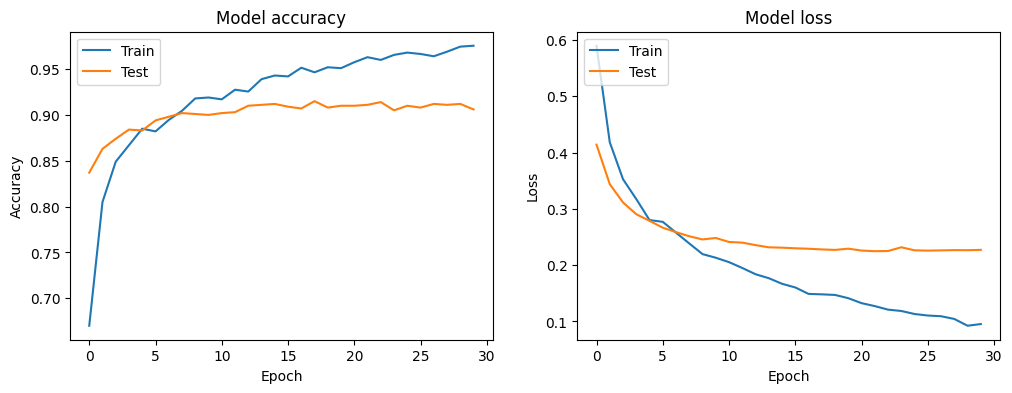

In [7]:
# plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

## Pre-trained part as an extended layer

In [8]:
network = models.Sequential()
network.add(layers.Input(shape=(150, 150, 3)))
network.add(layers.Rescaling(1.0 / 255))
network.add(data_augmentation)
network.add(conv_base)
network.add(layers.Flatten())
network.add(layers.Dense(256, activation="relu"))
network.add(layers.Dense(1, activation="sigmoid"))
network.summary()

conv_base.trainable = True
print(
    "Number of trainable weights before freezing the conv base: "
    f"{len(network.trainable_weights)}"
)

conv_base.trainable = False
print(
    "Number of trainable weights after freezing the conv base: "
    f"{len(network.trainable_weights)}"
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

Number of trainable weights before freezing the conv base: 30
Number of trainable weights after freezing the conv base: 4


## Fit the Model

In [9]:
network.compile(
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = network.fit(
    train_dataset,
    steps_per_epoch=100,
    epochs=30,
    validation_data=val_dataset,
    validation_steps=50,
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6065 - loss: 0.6546 - val_accuracy: 0.7890 - val_loss: 0.4967
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.7405 - loss: 0.5389 - val_accuracy: 0.7840 - val_loss: 0.4362
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7680 - loss: 0.4950 - val_accuracy: 0.8530 - val_loss: 0.3582
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7910 - loss: 0.4556 - val_accuracy: 0.8680 - val_loss: 0.3269
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8200 - loss: 0.4233 - val_accuracy: 0.8740 - val_loss: 0.3108
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8145 - loss: 0.4158 - val_accuracy: 0.8650 - val_loss: 0.3119
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8240 - loss: 0.3972 - val_accuracy: 0.8770 - val_loss: 0.2966
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8200 - loss: 0.3937 - val_accu

## Outcome Analysis

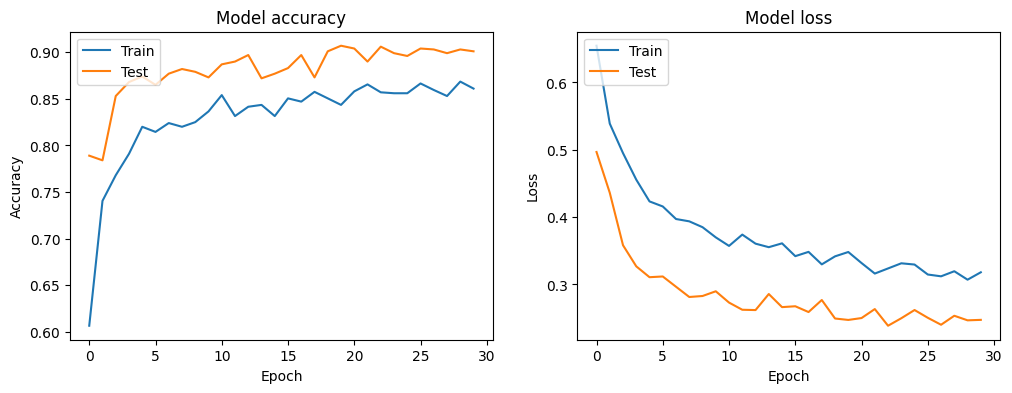

In [10]:
# plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()